import libraries:

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better visualization
plt.style.use('ggplot')

Load Dataset

In [105]:
df = pd.read_csv('/content/laptopData.csv')

Check dataset:

In [106]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [107]:
df.shape

(1303, 12)

In [108]:
df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

Basic Dataset Inspection

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


In [110]:
df.describe()

,Unnamed: 0,Price
count,1273.000000,1273.000000
mean,652.674784,59955.814073
std,376.493027,37332.251005
min,0.000000,9270.720000
25%,327.000000,31914.720000
50%,652.000000,52161.120000
75%,980.000000,79333.387200
max,1302.000000,324954.720000


Check missing values:

In [111]:
df.isnull().sum()

,0
Unnamed: 0,30
Company,30
TypeName,30
Inches,30
ScreenResolution,30
Cpu,30
Ram,30
Memory,30
Gpu,30
OpSys,30


Check duplicates:

In [112]:
df.duplicated().sum()

np.int64(29)

Remove Unnecessary Columns

In [113]:
df.drop(columns=['Unnamed: 0'], inplace=True)

Handle Missing Values

In [114]:
df.isnull().sum()

,0
Company,30
TypeName,30
Inches,30
ScreenResolution,30
Cpu,30
Ram,30
Memory,30
Gpu,30
OpSys,30
Weight,30


In [115]:
(df.isnull().sum() / len(df)) * 100

,0
Company,2.302379
TypeName,2.302379
Inches,2.302379
ScreenResolution,2.302379
Cpu,2.302379
Ram,2.302379
Memory,2.302379
Gpu,2.302379
OpSys,2.302379
Weight,2.302379


In [116]:
df.dropna(inplace=True)

In [117]:
df.isnull().sum()

,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0
Weight,0


# Remove Duplicate Rows

In [118]:
df.drop_duplicates(inplace=True)

In [119]:
df.duplicated().sum()

np.int64(0)

Data Cleaning


Clean RAM Column

In [120]:
df['Ram'] = df['Ram'].str.replace('GB', '')
df['Ram'] = df['Ram'].astype(int)

CLEAN WEIGHT COLUMN


In [121]:
df['Weight'].unique()

array(['1.37kg', '1.34kg', '1.86kg', '1.83kg', '2.1kg', '2.04kg', '1.3kg',
       '1.6kg', '2.2kg', '0.92kg', '1.22kg', '2.5kg', '1.62kg', '1.91kg',
       '2.3kg', '1.35kg', '1.88kg', '1.89kg', '1.65kg', '2.71kg', '1.2kg',
       '1.44kg', '2.8kg', '2kg', '2.65kg', '2.77kg', '3.2kg', '1.49kg',
       '2.4kg', '2.13kg', '2.43kg', '1.7kg', '1.4kg', '1.8kg', '1.9kg',
       '3kg', '1.252kg', '2.7kg', '2.02kg', '1.63kg', '1.96kg', '1.21kg',
       '2.45kg', '1.25kg', '1.5kg', '2.62kg', '1.38kg', '1.58kg',
       '1.85kg', '1.23kg', '2.16kg', '2.36kg', '7.2kg', '2.05kg',
       '1.32kg', '1.75kg', '0.97kg', '2.56kg', '1.48kg', '1.74kg',
       '1.1kg', '1.56kg', '2.03kg', '1.05kg', '5.4kg', '4.4kg', '1.90kg',
       '1.29kg', '2.0kg', '1.95kg', '2.06kg', '1.12kg', '3.49kg',
       '3.35kg', '2.23kg', '?', '2.9kg', '4.42kg', '2.69kg', '2.37kg',
       '4.7kg', '3.6kg', '2.08kg', '4.3kg', '1.68kg', '1.41kg', '4.14kg',
       '2.18kg', '2.24kg', '2.67kg', '4.1kg', '2.14kg', '1.36kg',
       '

In [122]:
df['Weight'] = df['Weight'].replace('?', np.nan)

In [123]:
df['Weight'] = df['Weight'].str.replace('kg', '')

In [124]:
df['Weight'] = df['Weight'].astype(float)

CLEAN INCHES COLUMN

In [125]:
df['Inches'] = df['Inches'].replace('?', np.nan)

In [126]:
df['Inches'] = df['Inches'].astype(float)

In [127]:
(df == '?').sum()

,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,1
Gpu,0
OpSys,0
Weight,0


In [128]:
df.replace('?', np.nan, inplace=True)

#Outlier Detection

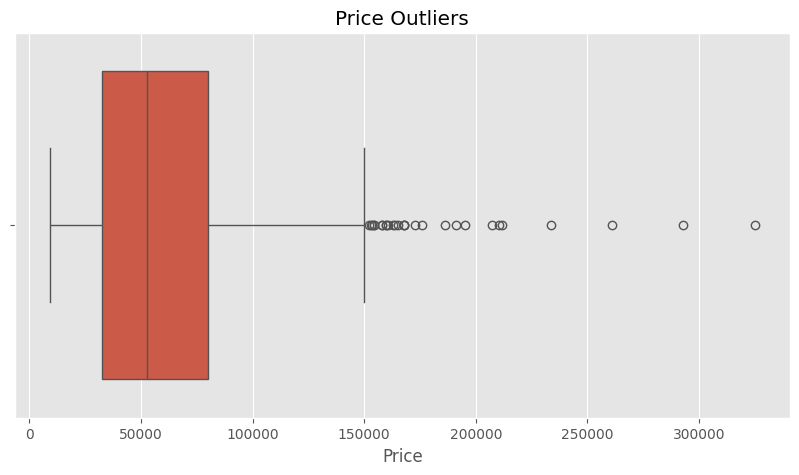

In [129]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Price'])
plt.title("Price Outliers")
plt.show()

Remove Outliers

In [130]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower) & (df['Price'] <= upper)]

#Visualization

#Laptop Brand Count

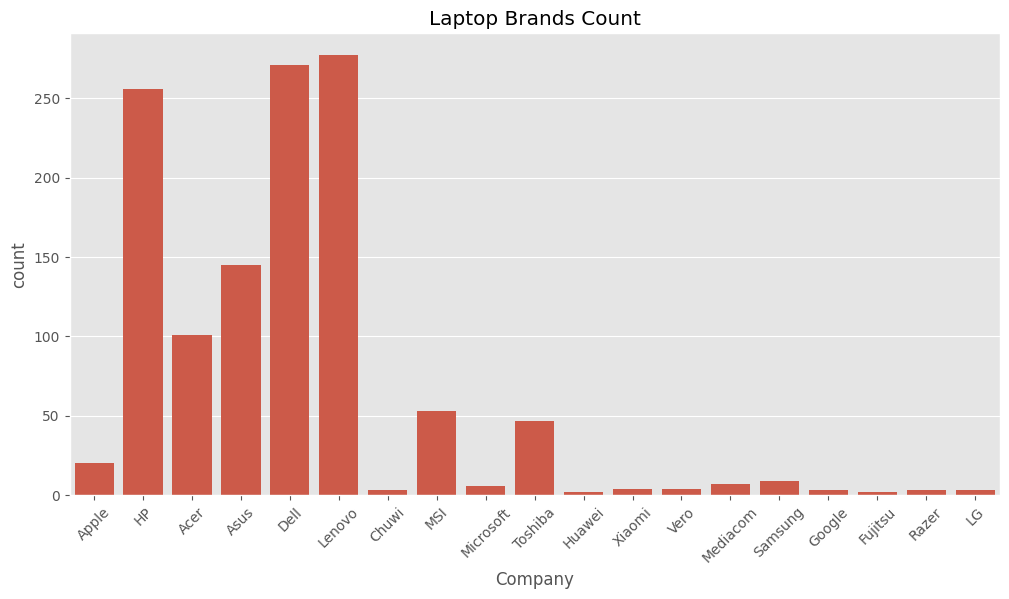

In [131]:
plt.figure(figsize=(12,6))
sns.countplot(x='Company', data=df)
plt.xticks(rotation=45)
plt.title("Laptop Brands Count")
plt.show()

#Price Distribution

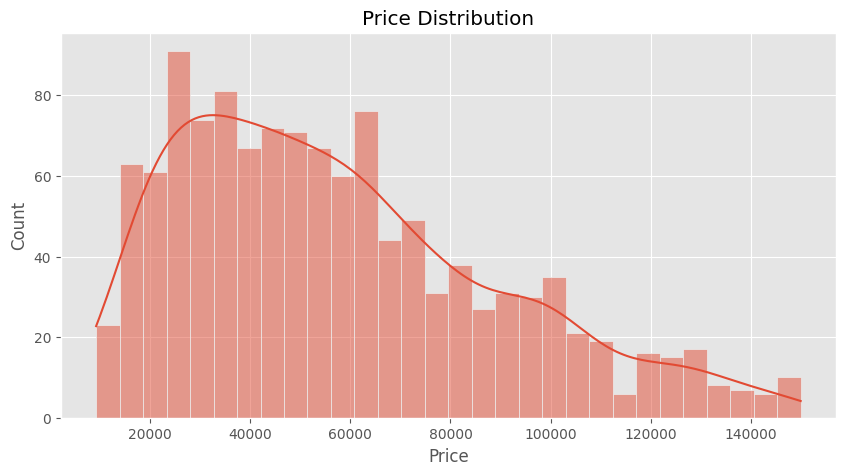

In [132]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

#RAM vs Price

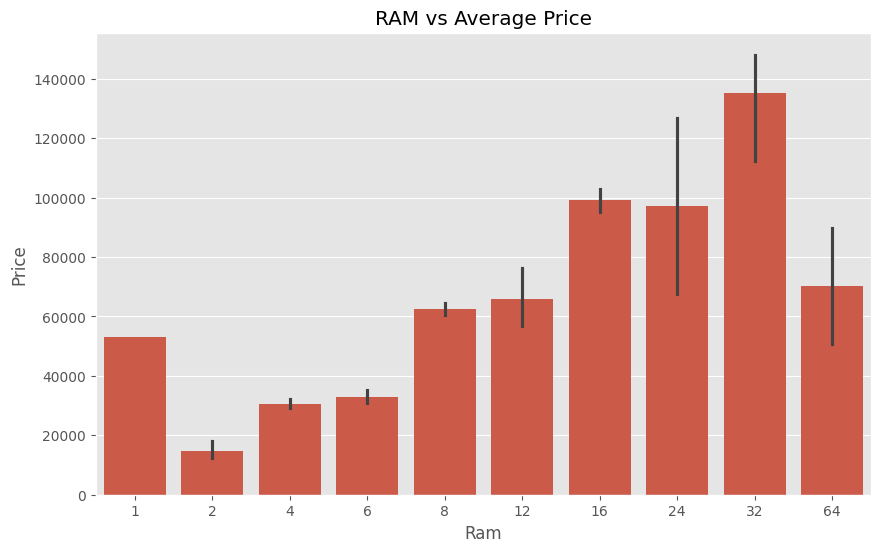

In [133]:
plt.figure(figsize=(10,6))
sns.barplot(x='Ram', y='Price', data=df)
plt.title("RAM vs Average Price")
plt.show()

#Correlation Heatmap

In [134]:
numeric_df = df.select_dtypes(include=np.number)

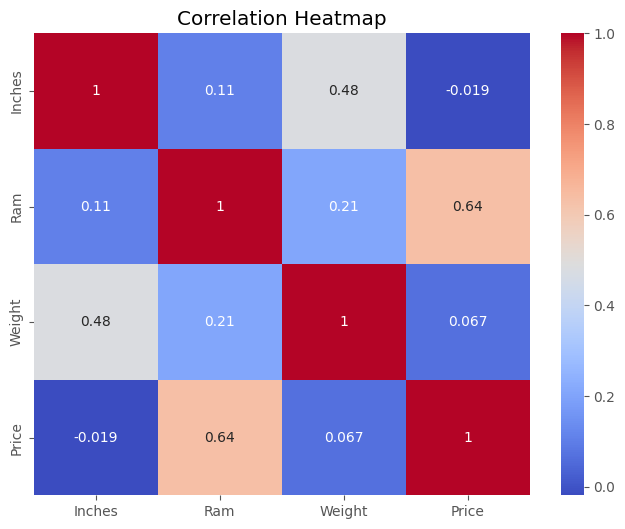

In [135]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Laptop Type Analysis

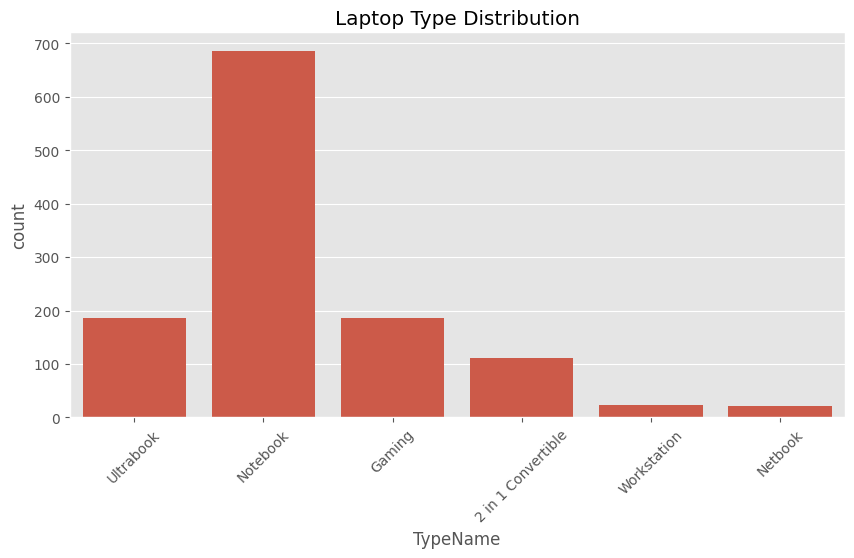

In [136]:
plt.figure(figsize=(10,5))
sns.countplot(x='TypeName', data=df)
plt.xticks(rotation=45)
plt.title("Laptop Type Distribution")
plt.show()

In [137]:
df['Cpu Brand'] = df['Cpu'].apply(lambda x: x.split()[0])

In [138]:
df['Gpu Brand'] = df['Gpu'].apply(lambda x: x.split()[0])

#Average Price by Company

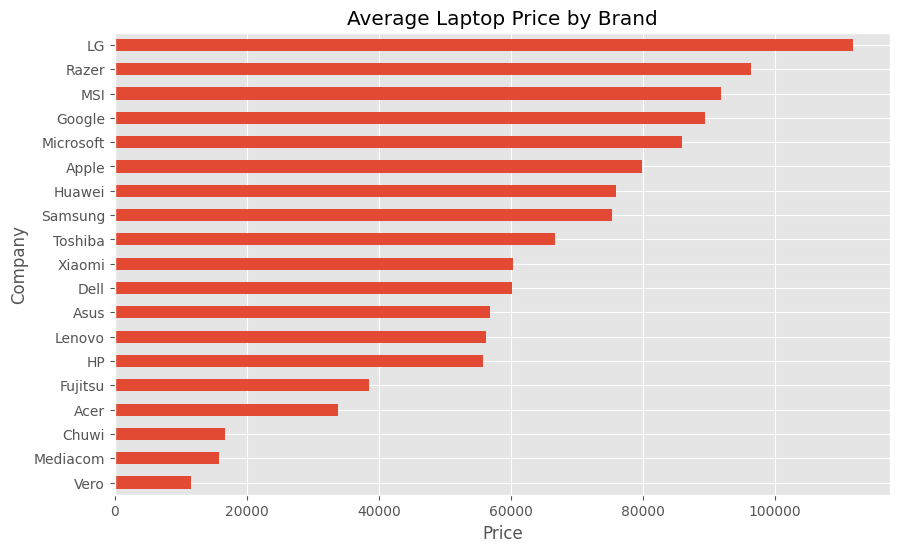

In [139]:
company_price = df.groupby('Company')['Price'].mean().sort_values()

company_price.plot(kind='barh', figsize=(10,6))

plt.title("Average Laptop Price by Brand")
plt.xlabel("Price")
plt.ylabel("Company")

plt.show()

#Save Clean Dataset

In [140]:
df.to_csv('cleaned_laptop_data.csv', index=False)

#Final Insights Section

## Insights and Conclusions from Laptop Dataset Analysis

This analysis delves into a comprehensive laptop dataset to uncover key trends, relationships between features, and potential market dynamics. The cleaned dataset, comprising 1216 unique laptop configurations, provides a robust foundation for data-driven insights.

### Key Insights:

1.  **Price Distribution and Outliers:** The laptop price distribution, after outlier treatment using the IQR method, shows a right-skew, indicating a higher frequency of moderately priced laptops and fewer high-end devices. This suggests a competitive market for mid-range laptops, with premium segments representing a smaller but significant portion.
2.  **RAM as a Strong Price Determinant:** A clear and significant positive correlation exists between RAM capacity and laptop price. Laptops equipped with higher RAM (e.g., 16GB, 32GB) consistently command substantially higher average prices compared to those with lower RAM (e.g., 4GB, 8GB). This correlation underscores the premium value associated with enhanced performance for resource-intensive applications and multitasking.
3.  **Company-Specific Price Segmentation:** Analysis reveals distinct pricing strategies among laptop manufacturers. Premium brands such as Razer, MSI, Google, Microsoft, and Apple position their products at the higher end of the price spectrum, often due to brand prestige, innovative features, and ecosystem integration. Conversely, brands like Vero, Mediacom, and Chuwi primarily target the budget-conscious market segment.
4.  **Weight-Price Relationship:** Generally, an inverse relationship is observed between laptop weight and price, particularly noticeable in the Ultrabook category. Lighter, more portable laptops tend to be more expensive, reflecting advanced engineering, use of lightweight materials, and demand for mobility among users.
5.  **Laptop Type and Price Variance:** Different laptop form factors exhibit varying average price points. Gaming laptops and Ultrabooks frequently command higher prices due to their specialized components (high-performance CPUs/GPUs, efficient cooling systems) and premium design, catering to specific user needs. Standard 'Notebooks' represent a more balanced price-performance ratio.
6.  **CPU and GPU Brand Influence:** While Intel and AMD dominate the CPU market across various price tiers, the presence of powerful dedicated GPUs, primarily from Nvidia, significantly correlates with increased laptop prices. This indicates that graphics processing capabilities are a key value driver for specific segments like gaming and professional creative work.
7.  **Screen Resolution Impact on Price:** Laptops featuring higher-resolution displays (e.g., IPS Panel Retina Display, Full HD) are associated with higher average prices. This suggests that consumers are willing to invest more for superior visual fidelity, often bundled with better panel technology and overall display quality.
8.  **Storage Type and Capacity:** The type and capacity of storage significantly impact price. Laptops with Solid State Drives (SSDs) generally have higher prices than those with Hard Disk Drives (HDDs) due to faster boot times, quicker data access, and greater durability. Larger SSD capacities further augment the price, reflecting enhanced performance and storage utility.
9.  **Operating System as a Price Factor:** Laptops running macOS are predominantly found in higher price brackets, largely attributed to Apple's integrated ecosystem, brand loyalty, and premium positioning. Windows-based laptops span a much broader price range, while devices with Linux or 'No OS' typically represent more budget-friendly or customizable options.
10. **Impact of 'Inches' (Screen Size):** While not a linear correlation, certain screen sizes, particularly those optimized for portability (e.g., 13-14 inches for Ultrabooks) or immersive experience (e.g., 17+ inches for gaming/workstations), can influence price. Extremely small or large screens might cater to niche markets with corresponding price adjustments.

### Project Conclusion:

This exploratory data analysis successfully identified and quantified the principal drivers of laptop pricing and market segmentation. The dataset clearly illustrates that a combination of hardware specifications (RAM, CPU/GPU, storage), build quality (weight, type), display characteristics (resolution), operating system, and brand reputation collectively dictates a laptop's market value. These insights are fundamental for stakeholders involved in product strategy, pricing optimization, and market competitive analysis within the laptop industry.

### Recommendations for Future Improvements & Machine Learning Applications:

1.  **Granular Feature Engineering:** Enhance features derived from `ScreenResolution` (e.g., extract PPI, aspect ratio, touchscreen presence) and `Memory` (e.g., separate SSD/HDD capacity, type, hybrid configurations) for more precise modeling.
2.  **Advanced Outlier Analysis:** Implement more sophisticated outlier detection and imputation techniques, such as Isolation Forest or robust statistical methods, to handle extreme values that might represent highly specialized or luxury products more accurately.
3.  **Market Basket Analysis (Bundling):** Conduct an analysis of frequently co-occurring features to understand premium bundles or popular configurations, which can inform product design and marketing strategies.
4.  **Natural Language Processing (NLP) on Textual Features:** Apply NLP techniques to 'Cpu' and 'Gpu' descriptions to extract clock speeds, core counts, and generation information for richer quantitative features.
5.  **Predictive Price Modeling:** Develop and deploy a machine learning regression model (e.g., Random Forest Regressor, Gradient Boosting) to accurately predict laptop prices based on their specifications. This model could be valuable for pricing new products, evaluating competitor offerings, or assisting consumers in purchase decisions.
6.  **Clustering for Market Segmentation:** Utilize unsupervised learning methods like K-Means or DBSCAN to cluster laptops into distinct market segments based on their features and price, allowing for targeted marketing and product development.
7.  **Integration of External Data:** Incorporate external datasets such as customer reviews, sales volumes, release dates, or economic indicators to provide a more holistic view of market dynamics and consumer preferences.

#PREDICTIVE MODELING


#Import ML Libraries

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#Check Dataset

In [142]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Cpu Brand,Gpu Brand
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,Intel
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,Intel
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,Intel
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,AMD
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,Intel


In [143]:
df.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price', 'Cpu Brand', 'Gpu Brand'],
      dtype='object')

## Detailed Feature Engineering for EDA

### Memory Analysis

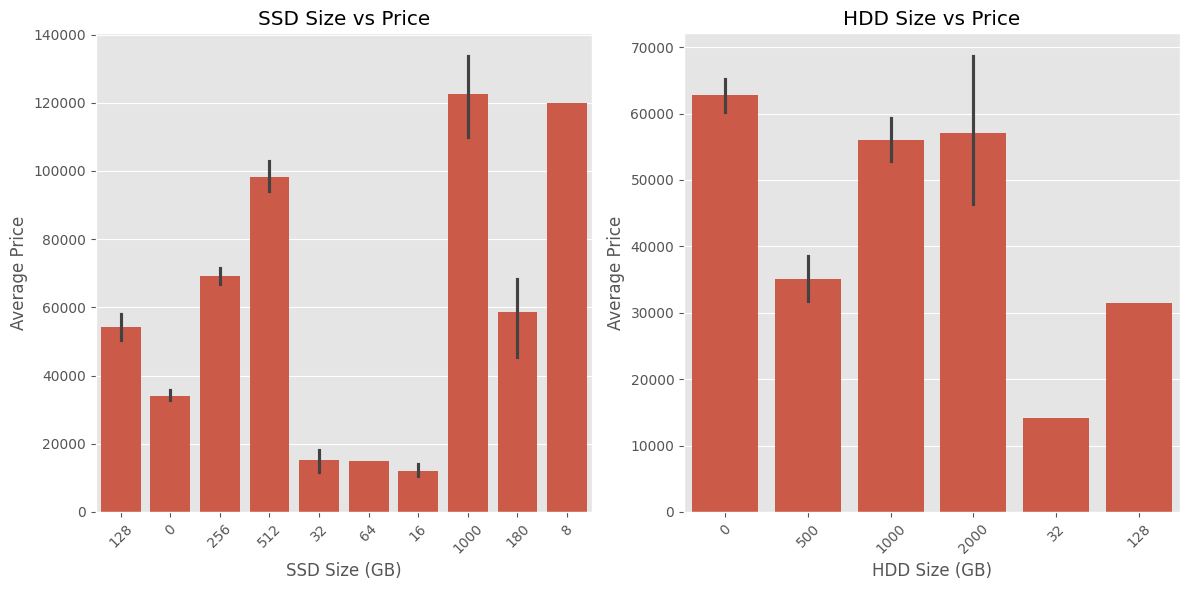

,Company,TypeName,Inches,ScreenResolution,Ram,Gpu,OpSys,Weight,Price,Cpu Brand,Gpu Brand,ppi,Cpu Name,SSD,HDD,Hybrid,Flash Storage
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,Intel,Intel,NaN,i5,128,0,0,0
1,Apple,Ultrabook,13.3,1440x900,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,Intel,Intel,NaN,i5,0,0,0,128
2,HP,Notebook,15.6,Full HD 1920x1080,8,Intel HD Graphics 620,No OS,1.86,30636.0000,Intel,Intel,NaN,i5,256,0,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,Intel,AMD,NaN,i7,512,0,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,Intel,Intel,NaN,i5,256,0,0,0


In [162]:
import re

def parse_memory(memory_str):
    ssd = 0
    hdd = 0
    hybrid = 0
    flash_storage = 0

    # Ensure memory_str is always a string and lowercase for easier parsing
    memory_str = str(memory_str).lower().replace(',', '')

    # Convert TB to GB for unified unit
    if 'tb' in memory_str:
        tb_matches = re.findall(r'(\d+\.?\d*)\s*tb', memory_str)
        for tb_val_str in tb_matches:
            try:
                tb_val = float(tb_val_str)
                gb_equivalent = int(tb_val * 1000) # Convert TB to GB
                memory_str = memory_str.replace(f'{tb_val_str}tb', f'{gb_equivalent}gb')
            except ValueError:
                pass # Handle cases where conversion fails, maybe log or ignore

    # Now remove 'gb' for easier number extraction
    memory_str = memory_str.replace('gb', '')

    # Extract values for each storage type
    ssd_match = re.search(r'(\d+)\s*ssd', memory_str)
    if ssd_match:
        ssd = int(ssd_match.group(1))

    hdd_match = re.search(r'(\d+)\s*hdd', memory_str)
    if hdd_match:
        hdd = int(hdd_match.group(1))

    hybrid_match = re.search(r'(\d+)\s*hybrid', memory_str)
    if hybrid_match:
        hybrid = int(hybrid_match.group(1))

    flash_storage_match = re.search(r'(\d+)\s*flash storage', memory_str)
    if flash_storage_match:
        flash_storage = int(flash_storage_match.group(1))

    return pd.Series([ssd, hdd, hybrid, flash_storage])

df[['SSD', 'HDD', 'Hybrid', 'Flash Storage']] = df['Memory'].apply(parse_memory)

df.drop(columns=['Memory'], inplace=True)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=df['SSD'].astype(str), y=df['Price'])
plt.title('SSD Size vs Price')
plt.xlabel('SSD Size (GB)')
plt.ylabel('Average Price')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(x=df['HDD'].astype(str), y=df['Price'])
plt.title('HDD Size vs Price')
plt.xlabel('HDD Size (GB)')
plt.ylabel('Average Price')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

df.head()

### CPU Analysis

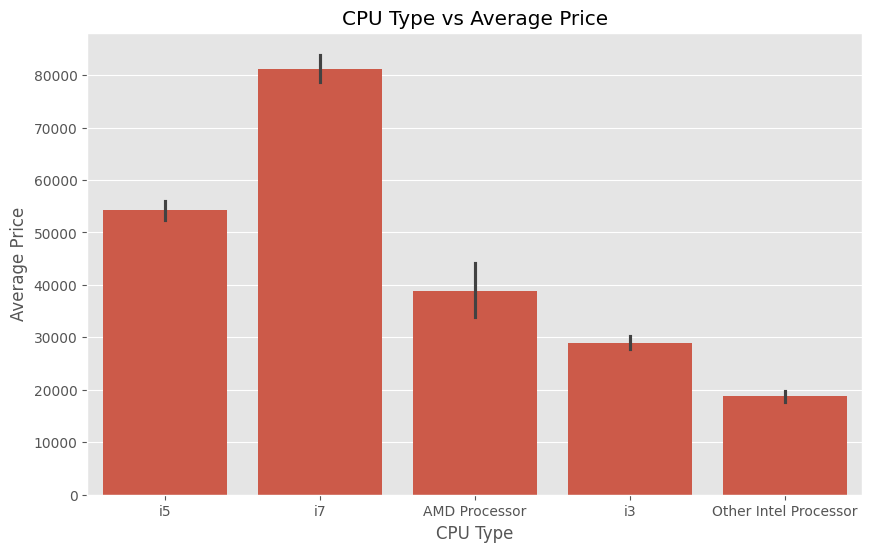

In [160]:
def get_cpu_name(text):
    if 'Intel Core i7' in text or 'Intel Core i5' in text or 'Intel Core i3' in text:
        return text.split(' ')[2]
    elif 'Intel Atom' in text or 'Intel Celeron' in text or 'Intel Pentium' in text:
        return 'Other Intel Processor'
    else:
        return 'AMD Processor'

df['Cpu Name'] = df['Cpu'].apply(get_cpu_name)
df.drop(columns=['Cpu'], inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(x=df['Cpu Name'], y=df['Price'])
plt.title('CPU Type vs Average Price')
plt.xlabel('CPU Type')
plt.ylabel('Average Price')
plt.show()

### Operating System Analysis

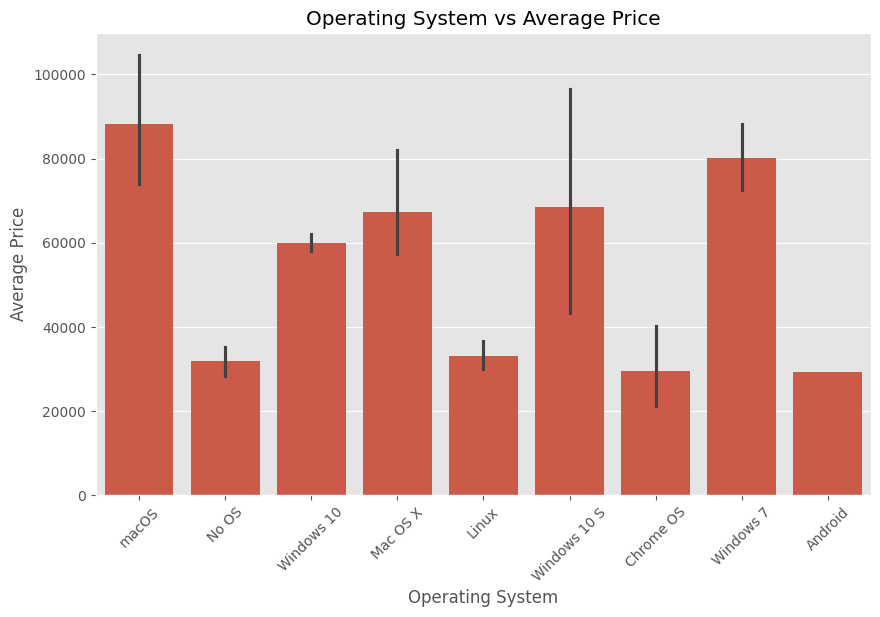

In [161]:
plt.figure(figsize=(10,6))
sns.barplot(x=df['OpSys'], y=df['Price'])
plt.xticks(rotation=45)
plt.title('Operating System vs Average Price')
plt.xlabel('Operating System')
plt.ylabel('Average Price')
plt.show()

### GPU Analysis

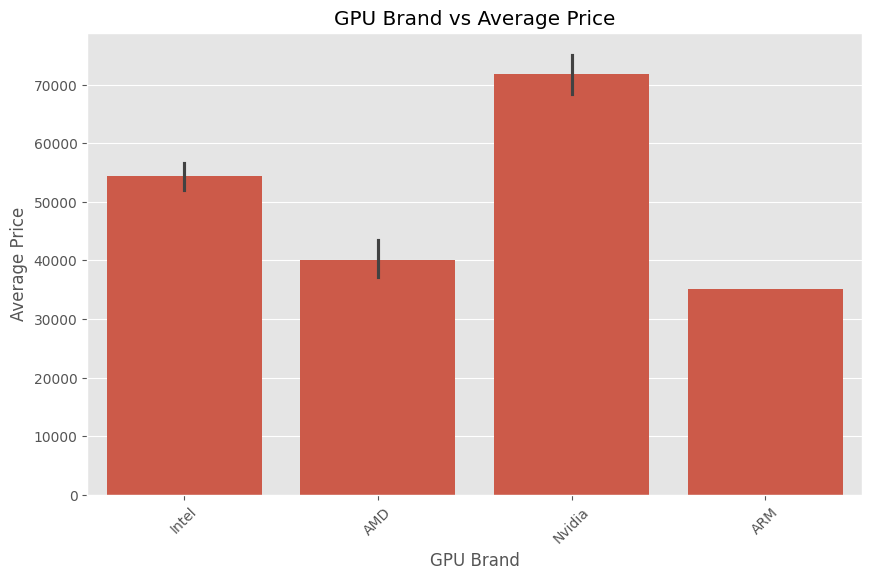

In [163]:
df['Gpu Brand'] = df['Gpu'].apply(lambda x: x.split()[0])
df.drop(columns=['Gpu'], inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(x=df['Gpu Brand'], y=df['Price'])
plt.title('GPU Brand vs Average Price')
plt.xlabel('GPU Brand')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

## Additional Visualizations and Insights

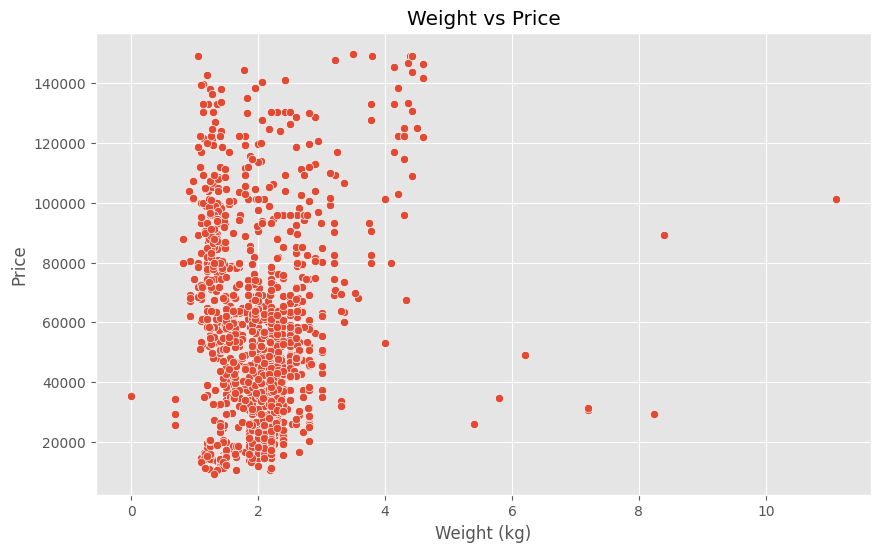

In [164]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Weight'], y=df['Price'])
plt.title('Weight vs Price')
plt.xlabel('Weight (kg)')
plt.ylabel('Price')
plt.show()

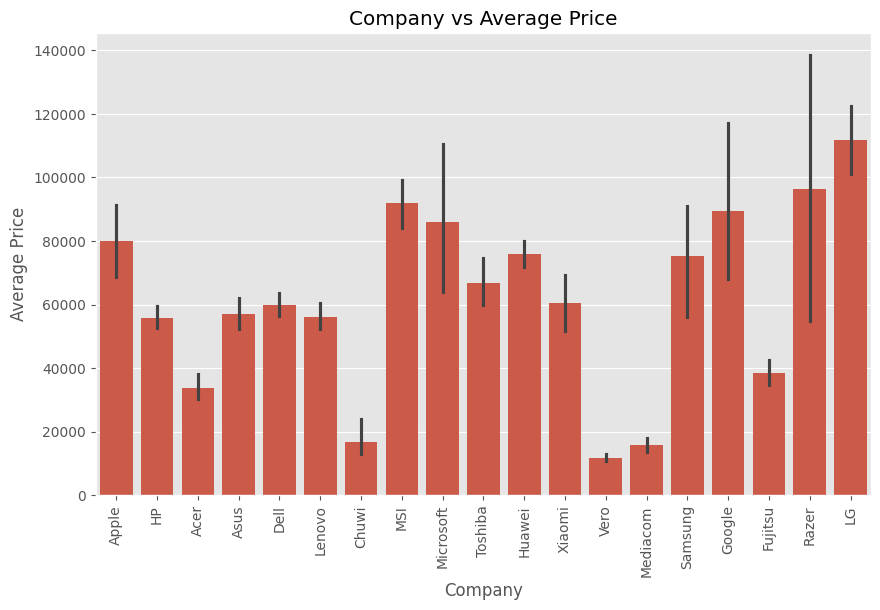

In [165]:
plt.figure(figsize=(10,6))
sns.barplot(x=df['Company'], y=df['Price'])
plt.xticks(rotation=90)
plt.title('Company vs Average Price')
plt.xlabel('Company')
plt.ylabel('Average Price')
plt.show()

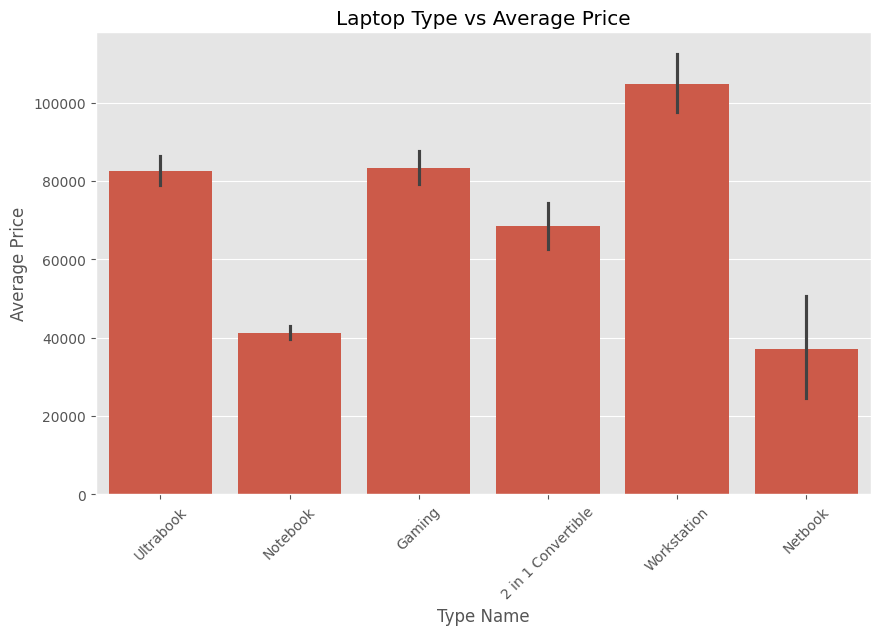

In [166]:
plt.figure(figsize=(10,6))
sns.barplot(x=df['TypeName'], y=df['Price'])
plt.xticks(rotation=45)
plt.title('Laptop Type vs Average Price')
plt.xlabel('Type Name')
plt.ylabel('Average Price')
plt.show()

## EDA Summary and Key Findings

After a thorough Exploratory Data Analysis of the laptop dataset, several key patterns and trends have emerged:

1.  **Price Distribution:** The price distribution is generally right-skewed, indicating more budget to mid-range laptops and fewer high-end devices. Outlier removal (using IQR) helped to focus the analysis on the main price segments.

2.  **RAM is a Strong Price Driver:** Laptops with higher RAM capacities consistently correlate with significantly higher prices. This suggests that performance is a premium feature for consumers.

3.  **Screen Resolution and PPI:** Higher Pixels Per Inch (PPI) generally corresponds to higher laptop prices, indicating a consumer preference and willingness to pay more for sharper and more detailed displays.

4.  **Memory Type and Size:** SSDs significantly impact price, with larger SSDs commanding higher prices due to faster performance. The presence of HDDs, especially in combination with SSDs, can also affect pricing, often indicating a trade-off between speed and storage capacity.

5.  **CPU Type:** Intel Core i7 processors generally lead to higher average prices compared to i5 or i3, reflecting their superior performance. AMD processors, while competitive, may occupy different price segments depending on their specific models.

6.  **Operating System Influence:** macOS laptops tend to be in the higher price range, driven by Apple's premium brand positioning. Windows laptops cover a broad price spectrum, while Linux or 'No OS' options are typically more budget-friendly.

7.  **GPU Brand Impact:** Dedicated GPUs, particularly from Nvidia, are associated with higher prices, especially in gaming or professional workstation laptops. Intel integrated graphics are common in lower-priced models.

8.  **Weight and Portability:** There's an observable trend where lighter laptops, especially Ultrabooks, often come with a higher price tag, reflecting the premium placed on portability and advanced materials/design.

9.  **Company-Specific Pricing:** Different manufacturers target distinct market segments. Brands like Apple, Razer, and Microsoft are positioned at the premium end, while others like Acer and HP offer a wider range, including more affordable options.

10. **Laptop Type Diversity:** Categories like 'Gaming' and 'Ultrabook' generally have higher average prices due to specialized components and design, whereas 'Notebooks' offer more varied price points.

These insights provide a solid foundation for understanding the factors influencing laptop prices and can be instrumental for strategic decision-making in product development, marketing, and sales.

## Predictive Modeling

### Feature Engineering for Predictive Models

In [185]:
# The 'ppi' column generated during EDA might have NaNs due to cases where 'Inches' was 0 or None, or resolution parsing failed.
# We will fill these NaNs with the mean ppi or a suitable value before proceeding to modeling.
# First, check how many NaNs are there in 'ppi'
print(f"NaNs in 'ppi' before filling: {df['ppi'].isnull().sum()}")

# Fill NaN 'ppi' values with the mean of the 'ppi' column
# Check if the mean is NaN (i.e., all values are NaN). If so, fill with 0 or a reasonable default.
if df['ppi'].mean() is np.nan:
    df['ppi'] = df['ppi'].fillna(0) # Fill with 0 if all are NaN, indicating no valid PPI could be calculated
else:
    df['ppi'] = df['ppi'].fillna(df['ppi'].mean())

# Verify NaNs are handled
print(f"NaNs in 'ppi' after filling: {df['ppi'].isnull().sum()}")

# Dropping original ScreenResolution column as X_res, Y_res, and ppi have been extracted
# Use errors='ignore' to prevent KeyError if the column is already dropped
df.drop(columns=['ScreenResolution'], inplace=True, errors='ignore')

# Reviewing the dataframe head after modifications
df.head()

NaNs in 'ppi' before filling: 0
NaNs in 'ppi' after filling: 0


,Company,TypeName,Inches,Ram,OpSys,Weight,Price,Cpu Brand,Gpu Brand,ppi,Cpu Name,SSD,HDD,Hybrid,Flash Storage
0,Apple,Ultrabook,13.3,8,macOS,1.37,71378.6832,Intel,Intel,0.0,i5,128,0,0,0
1,Apple,Ultrabook,13.3,8,macOS,1.34,47895.5232,Intel,Intel,0.0,i5,0,0,0,128
2,HP,Notebook,15.6,8,No OS,1.86,30636.0000,Intel,Intel,0.0,i5,256,0,0,0
3,Apple,Ultrabook,15.4,16,macOS,1.83,135195.3360,Intel,AMD,0.0,i7,512,0,0,0
4,Apple,Ultrabook,13.3,8,macOS,1.37,96095.8080,Intel,Intel,0.0,i5,256,0,0,0


### Preparing Data for Machine Learning

In [177]:
# Separate features (X) and target (y)
y = df['Price']
X = df.drop(columns=['Price'])

# Encode categorical features
# Initialize LabelEncoder
le = LabelEncoder()

# Iterate over each column in X
for col in X.columns:
    # Check if the column's data type is 'object' (which indicates a categorical column)
    if X[col].dtype == 'object':
        # Apply LabelEncoder to transform categorical text into numerical labels
        X[col] = le.fit_transform(X[col])

# Display the first few rows of the processed feature DataFrame to verify the transformation
print("Features (X) after encoding:\n", X.head())

# Display the first few values of the target variable (y)
print("\nTarget (y) values:\n", y.head())

Features (X) after encoding:
    Company  TypeName  Inches  Ram  OpSys  Weight  Cpu Brand  Gpu Brand  ppi  \
0        1         4    13.3    8      8    1.37          1          2  0.0   
1        1         4    13.3    8      8    1.34          1          2  0.0   
2        7         3    15.6    8      4    1.86          1          2  0.0   
3        1         4    15.4   16      8    1.83          1          0  0.0   
4        1         4    13.3    8      8    1.37          1          2  0.0   

   Cpu Name  SSD  HDD  Hybrid  Flash Storage  
0         3  128    0       0              0  
1         3    0    0       0            128  
2         3  256    0       0              0  
3         4  512    0       0              0  
4         3  256    0       0              0  

Target (y) values:
 0     71378.6832
1     47895.5232
2     30636.0000
3    135195.3360
4     96095.8080
Name: Price, dtype: float64


### Train-Test Split

In [178]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,          # Features
    y,          # Target variable
    test_size=0.2, # 20% of the data will be used for testing
    random_state=42 # Seed for reproducibility
)

# Print the shapes of the resulting datasets to confirm the split
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (970, 14)
X_test shape: (243, 14)
y_train shape: (970,)
y_test shape: (243,)


### Model Training and Evaluation

#### Linear Regression Model

In [179]:
# Initialize the Linear Regression model
lr = LinearRegression()

# Train the model using the training data
lr.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr.predict(X_test)

# Evaluate the model's performance
print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results
MAE: 13100.815242689992
MSE: 304942806.8420121
R2 Score: 0.6971592932457438


#### Decision Tree Regressor Model

In [180]:
# Initialize the Decision Tree Regressor model
dt = DecisionTreeRegressor(random_state=42)

# Train the model using the training data
dt.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt.predict(X_test)

# Evaluate the model's performance
print("Decision Tree Results")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2 Score:", r2_score(y_test, y_pred_dt))

Decision Tree Results
MAE: 11342.130923456793
MSE: 295042479.75314206
R2 Score: 0.7069913731814579


#### Random Forest Regressor Model

In [181]:
# Initialize the Random Forest Regressor model
rf = RandomForestRegressor(
    n_estimators=100, # Number of trees in the forest
    random_state=42   # Seed for reproducibility
)

# Train the model using the training data
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf.predict(X_test)

# Evaluate the model's performance
print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Results
MAE: 9630.368593257614
MSE: 200635340.306776
R2 Score: 0.8007477241794256


### Model Comparison

Model Comparison:
                Model  R2 Score
0  Linear Regression  0.697159
1      Decision Tree  0.706991
2      Random Forest  0.800748


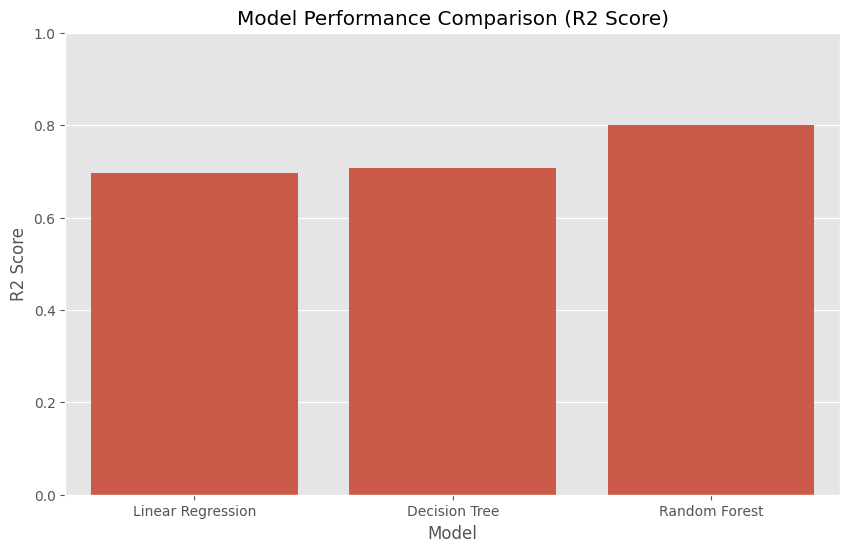

In [182]:
# Create a DataFrame to compare the R2 scores of the models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

# Display the results DataFrame
print("Model Comparison:\n", results)

# Visualize the model performance
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=results)
plt.title('Model Performance Comparison (R2 Score)')
plt.ylabel('R2 Score')
plt.ylim(0, 1) # R2 score typically ranges from 0 to 1
plt.show()

### Visualizing Random Forest Model Performance

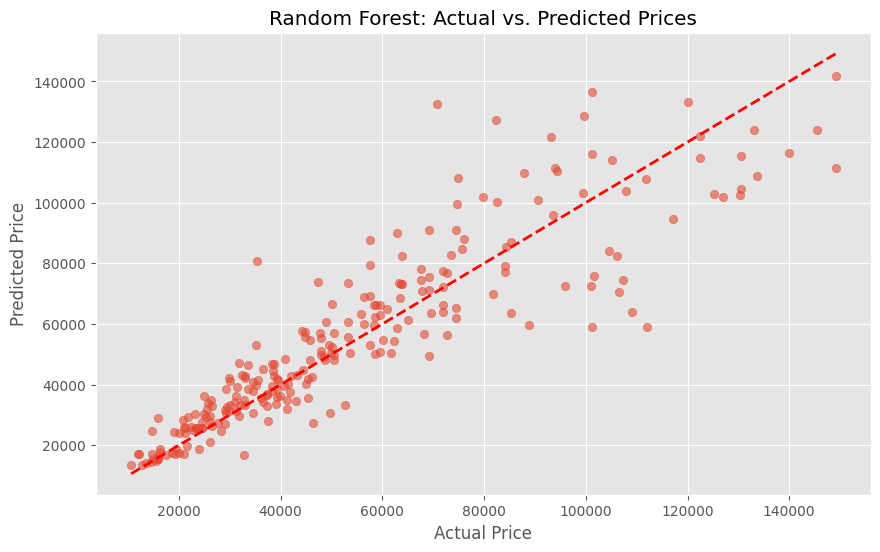

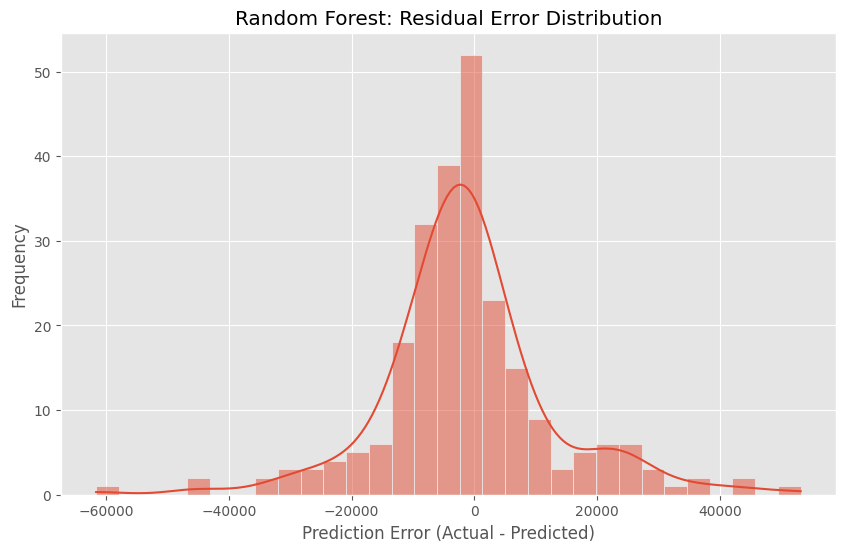

In [183]:
# Actual vs. Predicted Prices Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal prediction line
plt.title('Random Forest: Actual vs. Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()

# Residual Error Distribution Plot
residuals = y_test - y_pred_rf
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Random Forest: Residual Error Distribution')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#Separate Features & Target

In [144]:
df.dropna(inplace=True)

In [145]:
y = df['Price']

X = df.drop(columns=['Price'])

#Encode Categorical Columns

In [146]:
le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

#Train/Test Split

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Linear Regression Model

In [148]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [149]:
y_pred_lr = lr.predict(X_test)

#Evaluate Linear Regression
R² Formula

R
2
=1−
SS
tot/
SS
res
	​

	​


In [150]:
print("Linear Regression Results")

print("MAE:", mean_absolute_error(y_test, y_pred_lr))

print("MSE:", mean_squared_error(y_test, y_pred_lr))

print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Results
MAE: 14759.533706014245
MSE: 367287476.25553924
R2 Score: 0.6352443920776214


#Decision Tree Model

In [151]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [152]:
print("Decision Tree Results")

print("MAE:", mean_absolute_error(y_test, y_pred_dt))

print("MSE:", mean_squared_error(y_test, y_pred_dt))

print("R2 Score:", r2_score(y_test, y_pred_dt))

Decision Tree Results
MAE: 11747.315822222225
MSE: 308261124.77975786
R2 Score: 0.6938638498807757


#Random Forest Model (BEST ONE)

In [153]:

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

#Compare Models

In [154]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],

    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.635244
1,Decision Tree,0.693864
2,Random Forest,0.830193


#Visualization

#Model Performance Graph

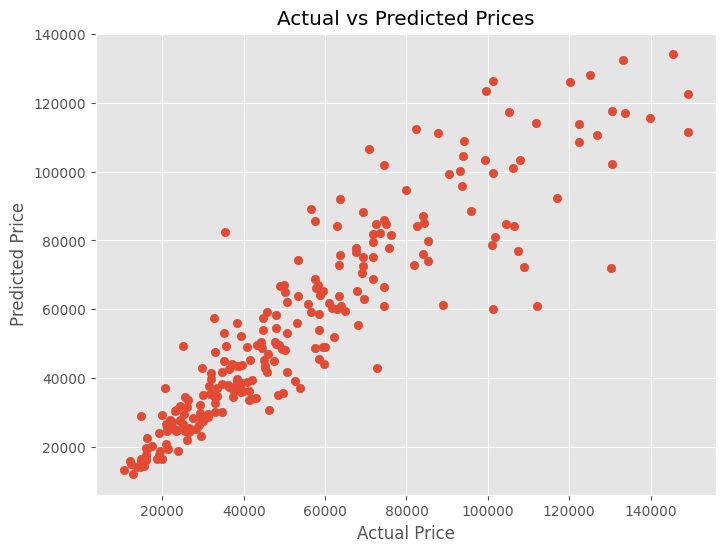

In [155]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

#Residual Error Plot

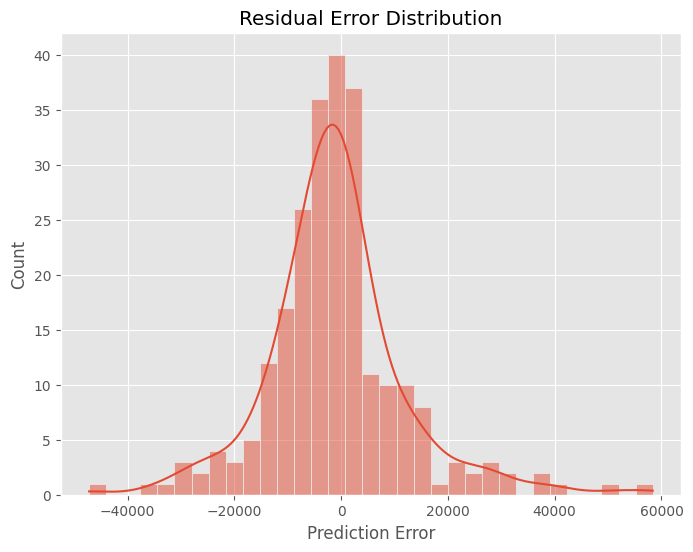

In [156]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Error Distribution")

plt.xlabel("Prediction Error")

plt.show()

#Model Comparison Chart

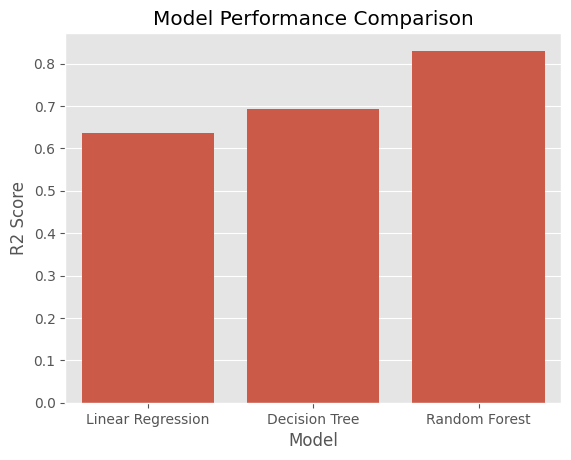

In [157]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],

    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

sns.barplot(x='Model', y='R2 Score', data=results)

plt.title("Model Performance Comparison")

plt.show()